## LiDAR-Based Tree Detection in Mixed Forests
## Task 5 : Convert Point Cloud to Voxel Grid



In [1]:
%%capture
! pip install laspy open3d

In [69]:
# Standard library imports
import os
import warnings
import collections
import itertools
from typing import Tuple, List, Union, Generator

# Numerical and data manipulation libraries
import numpy as np
import pandas as pd
import scipy
from scipy.spatial import KDTree

# Geospatial libraries
import geopandas as gpd
import open3d as o3d


# LAS (LiDAR) file handling
import laspy
from laspy import read

# Visualization libraries
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
import matplotlib.colors as mcolors
import seaborn as sns
from matplotlib import cm


from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models



In [2]:
def load_las_file(file_path: str) -> laspy.LasData:
    """
    Load a .las file and return the full laspy.LasData object.
    """
    try:
        las = laspy.read(file_path)
        return las  
    except Exception as e:
        print(f"Error loading file: {e}")
        return None


In [3]:
def shift_points_to_origin(points) -> np.ndarray:
    """
    Shift points to the origin (0, 0, 0) by subtracting the minimum coordinates.
    """
    return points - points.min(axis=0, keepdims=True)

In [4]:
def plot_shifted_lidar(lidar_file: str):
    """
    Plot a 3D LiDAR point cloud with ground points in red. Coordinates are shifted for better visualization.
    """
    try:
        las = laspy.read(lidar_file)
        points = np.stack([las.x, las.y, las.z], axis=1)
        classifications = las.classification

        # shift points to start from (0, 0, 0)
        points = shift_points_to_origin(points)
        ground_mask = classifications == 2
        ground_points = points[ground_mask]
        other_points = points[~ground_mask]

        file_name = os.path.splitext(os.path.basename(lidar_file))[0]

        fig = plt.figure(figsize=(6, 6))
        ax = fig.add_subplot(111, projection="3d")

        ax.scatter(
            ground_points[:, 0],
            ground_points[:, 1],
            ground_points[:, 2],
            c="red",
            s=0.5,
            label="Ground Points",
        )

        ax.scatter(
            other_points[:, 0],
            other_points[:, 1],
            other_points[:, 2],
            c=other_points[:, 2],
            cmap="viridis",
            s=0.5,
        )

        ax.set_title("LiDAR Point Cloud Visualization (Shifted)")
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")  

        ax.view_init(elev=30, azim=45)  
        ax.legend(loc="upper right", markerscale=5, fontsize=10)

        plt.figtext(0.5, 0.01, f"{file_name}", ha="center", style="italic")

        plt.show()

    except Exception as e:
        print(f"Error visualizing LiDAR file: {e}")


In [5]:
def calculate_iqr_outliers(z_values: np.ndarray) -> Tuple[float, float]:
    """
    Calculate the lower and upper bounds for outliers in Z values based on the IQR method.
    """
    q1 = np.percentile(z_values, 25)  # 25th percentile (Q1)
    q3 = np.percentile(z_values, 75)  # 75th percentile (Q3)
    iqr = q3 - q1  # Interquartile range (IQR)
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    return lower_bound, upper_bound


In [6]:
def plot_z_distribution(z_values: np.ndarray, ax, file_name: str):
    """
    Plot the Z-value distribution for the given z-values on a specific subplot, with outlier boundaries.
    """
    lower_bound, upper_bound = calculate_iqr_outliers(z_values)
    
    # Plot histogram
    ax.hist(z_values, bins=50, color="green", alpha=0.7, label="Z Values")
    
    # Add IQR outlier lines
    ax.axvline(lower_bound, color="red", linestyle="--", label=f"Lower: {lower_bound:.2f}")
    ax.axvline(upper_bound, color="red", linestyle="--", label=f"Upper: {upper_bound:.2f}")
    
    ax.set_title(file_name, fontsize=10)
    ax.set_xlabel("Z Value (Height)", fontsize=8)
    ax.set_ylabel("Frequency", fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)


In [7]:
LAS_GROUND_CLASS = 2

def normalize_cloud_height(las) -> np.ndarray:

    out = las.xyz.copy()
    assert np.any(las.classification == LAS_GROUND_CLASS), "No ground classification points found."
    
    # Interpolate ground level heights
    ground_level = scipy.interpolate.griddata(
        points=las.xyz[las.classification == LAS_GROUND_CLASS, :2], # X, Y coordinates of ground points
        values=las.xyz[las.classification == LAS_GROUND_CLASS, 2], # Z-values (ground heights)
        xi=las.xyz[:, :2], # X, Y coordinates of all points
        method="nearest", # Interpolation method
    )
    
    # Subtract ground level from Z-values
    out[:, 2] -= ground_level
    return out

In [8]:
def preprocess_data(las) -> np.ndarray:
    """
    Preprocess LiDAR points by normalizing heights relative to ground and removing outliers.
    """
    normalized_cloud = normalize_cloud_height(las)
    
    # Extract Z-values
    z_values = [point[2] for point in normalized_cloud]
    lower_bound, upper_bound = calculate_iqr_outliers(z_values)
    mask = (z_values >= lower_bound) & (z_values <= upper_bound)
    
    filtered_points = normalized_cloud[mask]
    
    return filtered_points


In [9]:
def split_dataset(data: List, train_ratio: float = 0.7) -> Tuple[List, List]:
    """
    Splits the dataset into training and testing sets based on the given ratio.
    """
    split_idx = int(len(data) * train_ratio)
    
    train_data = data[:split_idx]
    test_data = data[split_idx:]
    
    return train_data, test_data

In [10]:
def local_maxima_filter(cloud: np.ndarray, window_size: float, height_threshold: float) -> np.ndarray:
    """Detect local maxima in the point cloud with a fixed window size."""
    
    assert isinstance(cloud, np.ndarray), f"Cloud needs to be a numpy array, not {type(cloud)}"
    
    cloud = cloud[cloud[:, 2] > height_threshold]
    tree = KDTree(data=cloud)
    seen_mask = np.zeros(cloud.shape[0], dtype=bool)
    local_maxima = []

    for i, point in enumerate(cloud):
        if seen_mask[i]:
            continue
        neighbor_indices = tree.query_ball_point(point, window_size)
        highest_neighbor = neighbor_indices[cloud[neighbor_indices, 2].argmax()]
        seen_mask[neighbor_indices] = True
        seen_mask[highest_neighbor] = False 
        # This may lead to not every point being marked as seen in the end, but it does not matter,
        # because by the time the seen value is overwritten the point is already processed
        if i == highest_neighbor:
            local_maxima.append(i)
    return cloud[local_maxima]

In [11]:
def _ndarray_to_tuple(array: np.ndarray) -> tuple:
    """Convert an array to a tuple, replacing np.nan with None."""
    return tuple(None if np.isnan(x) else x for x in array)

In [12]:
def match_candidates(
    ground_truth: np.ndarray,
    candidates: np.ndarray,
    *,
    max_distance: float,
    max_height_difference: float,
) -> list[dict]:
    """Match ground truth trees to candidates."""

    distance_matrix = scipy.spatial.distance_matrix(
        x=ground_truth[:, :2],
        y=candidates[:, :2],
    )
    indices = np.nonzero(distance_matrix <= max_distance)  # (ground_truths, candidates)
    distances = distance_matrix[indices]
    sparse_distances = sorted((d, pair) for d, pair in zip(distances, zip(*indices)))

    ground_truth_matched_mask = np.zeros(ground_truth.shape[0], dtype=bool)
    candidates_matched_mask = np.zeros(candidates.shape[0], dtype=bool)
    out = []

    for distance, (i, j) in sparse_distances:
        if ground_truth_matched_mask[i] and candidates_matched_mask[j]:
            continue

        if (
            not np.isnan(ground_truth[i][2])
            and abs(ground_truth[i][2] - candidates[j][2]) > max_height_difference
        ):
            continue

        if ground_truth_matched_mask[i]:
            candidates_matched_mask[j] = True
            out.append(
                {
                    "ground_truth": None,
                    "candidate": _ndarray_to_tuple(candidates[j]),
                    "class": "FP",
                    "distance": None,
                }
            )
        elif candidates_matched_mask[j]:
            ground_truth_matched_mask[i] = True
            out.append(
                {
                    "ground_truth": _ndarray_to_tuple(ground_truth[i]),
                    "candidate": None,
                    "class": "FN",
                    "distance": None,
                }
            )
        else:
            ground_truth_matched_mask[i] = True
            candidates_matched_mask[j] = True
            out.append(
                {
                    "ground_truth": _ndarray_to_tuple(ground_truth[i]),
                    "candidate": _ndarray_to_tuple(candidates[j]),
                    "class": "TP",
                    "distance": distance,
                }
            )

    out.extend(
        {
            "ground_truth": _ndarray_to_tuple(point),
            "candidate": None,
            "class": "FN",
            "distance": None,
        }
        for point in ground_truth[~ground_truth_matched_mask]
    )

    out.extend(
        {
            "ground_truth": None,
            "candidate": tuple(point),
            "class": "FP",
            "distance": None,
        }
        for point in candidates[~candidates_matched_mask]
    )

    return out

In [13]:
def crop_by_other(points: np.ndarray, other: np.ndarray) -> np.ndarray:
    """Crop points by the extent of other."""
    hull = scipy.spatial.ConvexHull(other[:, :2])
    vertex_points = hull.points[hull.vertices]
    delaunay = scipy.spatial.Delaunay(vertex_points)
    within_hull = delaunay.find_simplex(points[:, :2]) >= 0
    return points[within_hull]

In [14]:
def calculate_metrics(group):
    classes = collections.Counter(group["class"])
    metrics = {
        "recall": classes["TP"] / (classes["TP"] + classes["FN"]),
        "precision": classes["TP"] / (classes["TP"] + classes["FP"]),
    }
    if metrics["recall"] + metrics["precision"] > 0:
        metrics["f1"] = 2 * metrics["recall"] * metrics["precision"]
        metrics["f1"] = metrics["f1"] / (metrics["recall"] + metrics["precision"])
    else:
        metrics["f1"] = 0
    metrics["avg_dist"] = group["distance"].mean()
    return round(pd.Series(metrics), 2)

In [93]:
def to_voxel_grid(xyz: np.ndarray, voxel_size: float, file_path="voxel_grid.ply")-> o3d.geometry.VoxelGrid:
    """
    Convert a NumPy array point cloud to a voxel grid, apply a Viridis colormap based on Z-coordinate,
    save the voxel grid to a .ply file, and return the voxel grid.
    """
    # Convert NumPy array to Open3D PointCloud
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(xyz)

    # Apply Viridis colormap based on Z-coordinate
    cmap = get_cmap("viridis")
    norm = mcolors.Normalize(vmin=xyz[:, 2].min(), vmax=xyz[:, 2].max())
    colors = cmap(norm(xyz[:, 2]))[:, :3]  # Extract RGB values

    # Assign colors to the Open3D PointCloud
    pcd.colors = o3d.utility.Vector3dVector(colors)

    # Create a voxel grid from the colored PointCloud
    voxel_grid = o3d.geometry.VoxelGrid.create_from_point_cloud(pcd, voxel_size=voxel_size)

    # Save the voxel grid to a .ply file
    o3d.io.write_voxel_grid(file_path, voxel_grid)

    return voxel_grid


In [109]:
def load_and_visualize_voxel_grid(file_path: str):
    """
    Load a voxel grid from a .ply file and visualize it using Open3D.
    """
    # Load the voxel grid from the file
    voxel_grid = o3d.io.read_voxel_grid(file_path)
    
    # Check if the voxel grid was loaded successfully
    if voxel_grid is None:
        print(f"Failed to load voxel grid from {file_path}")
        return
    
    # Visualize the voxel grid
    o3d.visualization.draw_geometries([voxel_grid], window_name="Loaded Voxel Grid")
    print(f"Successfully loaded and visualized voxel grid from {file_path}")


In [16]:
def voxel_grid_to_array(voxel_grid, voxel_size):
    """
    Convert an Open3D VoxelGrid into a binary 3D voxel grid.
    """
    # Get the grid indices of the occupied voxels
    voxel_indices = np.array([voxel.grid_index for voxel in voxel_grid.get_voxels()])

    # Compute the dimensions of the grid
    bounding_box = voxel_grid.get_max_bound() - voxel_grid.get_min_bound()
    grid_shape = np.ceil(bounding_box / voxel_size).astype(int)

    # Create a binary 3D array (grid)
    binary_grid = np.zeros(grid_shape, dtype=np.uint8)
    for idx in voxel_indices:
        binary_grid[tuple(idx)] = 1  # Mark the voxel as occupied

    return binary_grid

In [85]:
def plot_voxel_centers(binary_voxel_grid: np.ndarray, voxel_size: float, title="Voxel Centers"):
    """
    Visualize voxel centers (occupied voxels) in binary format as squares with a Viridis colormap.
    """
    # Get indices of occupied voxels (where value is 1)
    occupied_indices = np.array(np.nonzero(binary_voxel_grid)).T

    # Scale indices by voxel size to get real-world coordinates
    voxel_centers = occupied_indices * voxel_size

    # Apply Viridis colormap based on Z-coordinate
    cmap = get_cmap("viridis")
    norm = mcolors.Normalize(vmin=voxel_centers[:, 2].min(), vmax=voxel_centers[:, 2].max())
    colors = cmap(norm(voxel_centers[:, 2]))[:, :3]  # Extract RGB values

    # Create an Open3D PointCloud
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(voxel_centers)
    pcd.colors = o3d.utility.Vector3dVector(colors)

    # Visualize the point cloud with colors
    o3d.visualization.draw_geometries([pcd], window_name=title)


In [18]:
def world_to_voxel_indices(x, y, min_bound, voxel_size):
    """
    Convert world coordinates (x, y) to voxel grid indices.
    """
    voxel_x = int(np.floor((x - min_bound[0]) / voxel_size))
    voxel_y = int(np.floor((y - min_bound[1]) / voxel_size))
    return voxel_x, voxel_y


### Preprocessing

In [19]:
plot_las_files = [f"../data/als/plot_{i:02d}.las" for i in range(1, 11)]

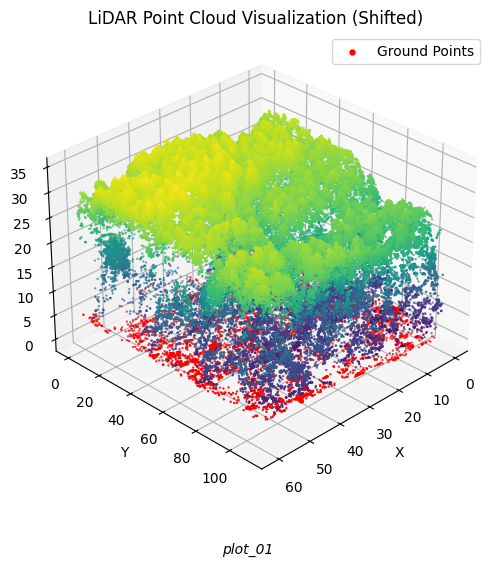

In [20]:
plot_shifted_lidar(plot_las_files[0])

Processing plot_01.las... : (218873 Points)
Processing plot_02.las... : (355599 Points)
Processing plot_03.las... : (301556 Points)
Processing plot_04.las... : (251251 Points)
Processing plot_05.las... : (105771 Points)
Processing plot_06.las... : (297806 Points)
Processing plot_07.las... : (312711 Points)
Processing plot_08.las... : (268913 Points)
Processing plot_09.las... : (312514 Points)
Processing plot_10.las... : (314188 Points)


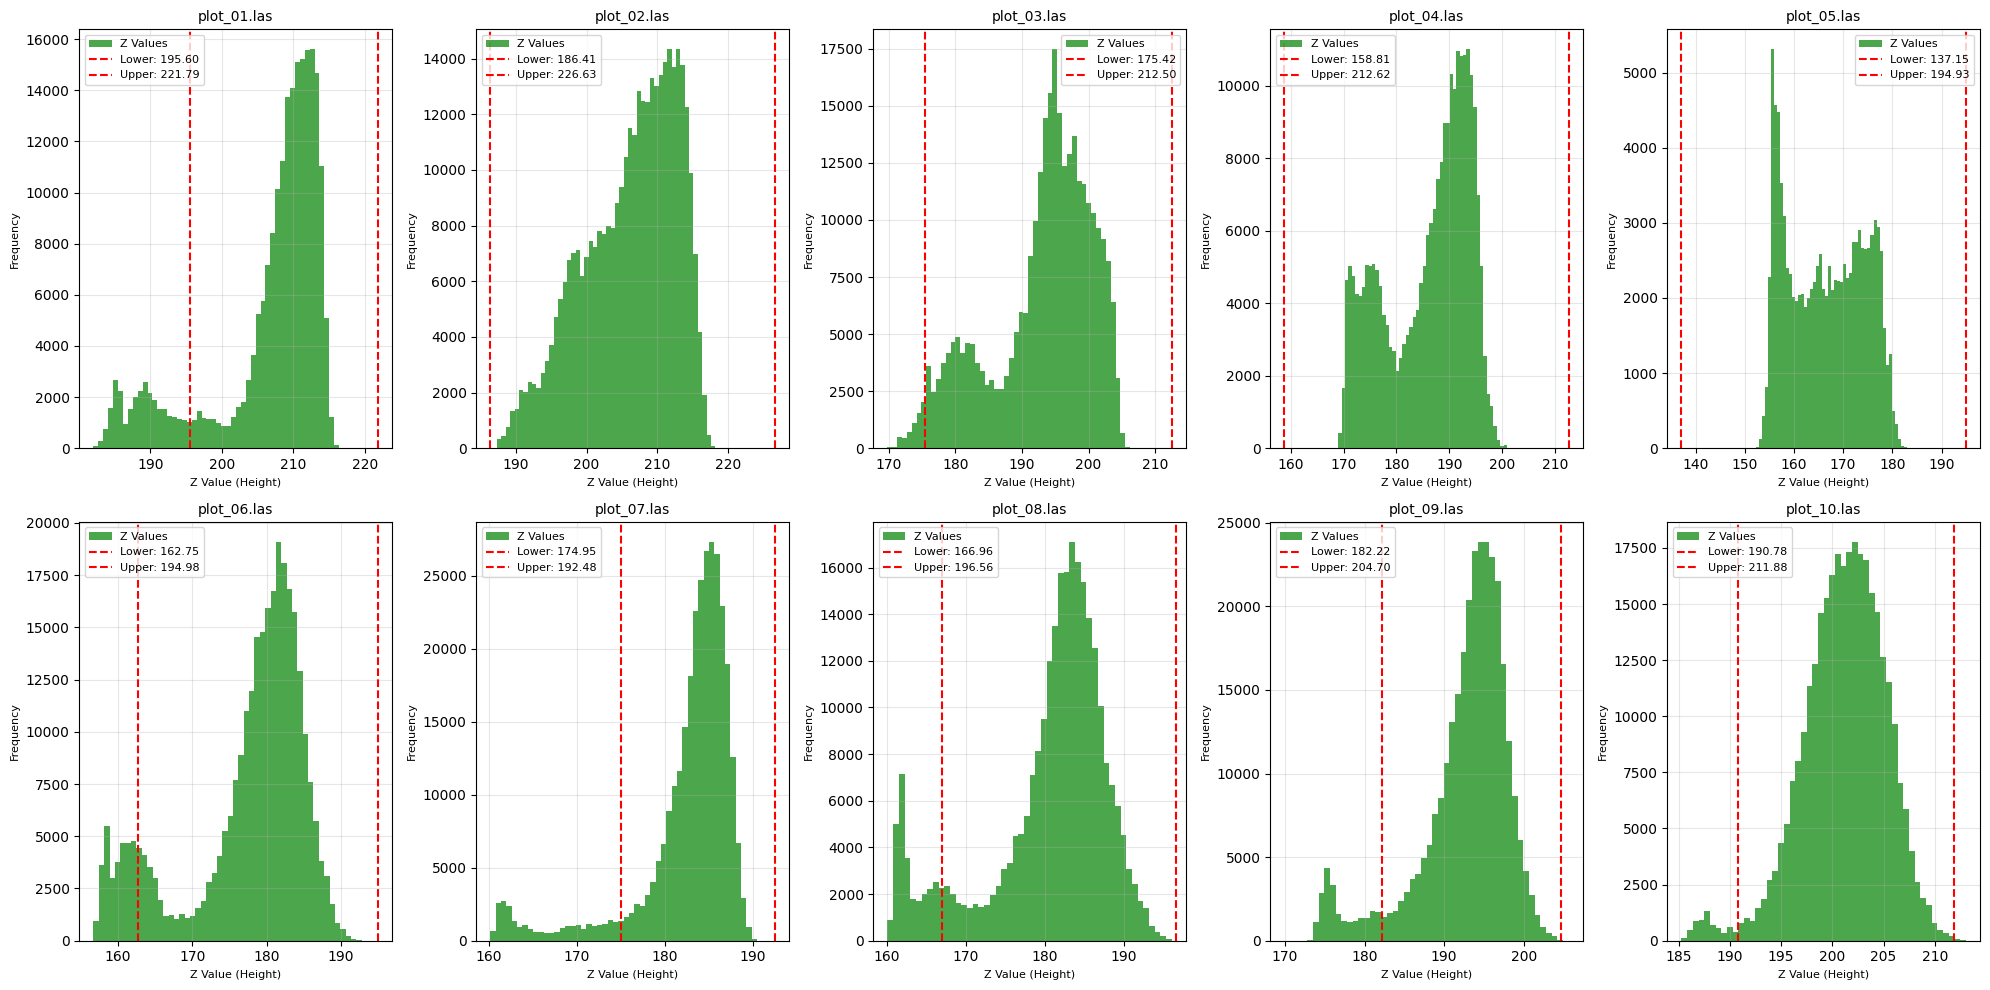

In [21]:
fig, axes = plt.subplots(2, 5, figsize=(20, 10))  
axes = axes.flatten()  

for i, file_path in enumerate(plot_las_files[:10]):  
    file_name = os.path.basename(file_path)
    las = load_las_file(file_path)

    print(f"Processing {file_name}... : ({len(las)} Points)")
    if las is None or len(las.x) == 0:  
        print(f"Skipping {file_name} due to an error or no valid points.")
        continue
    
    plot_z_distribution(las.z, axes[i], file_name)

plt.tight_layout()
plt.show()


In [22]:
field_survey_gpd = gpd.read_file("../data/field_survey.geojson")
field_survey_gpd["coords"] = field_survey_gpd.get_coordinates().apply(
    lambda x: (x["x"], x["y"]),
    axis=1,
)

In [23]:
preprocessed_data = []  

for file_path in plot_las_files:
    
    las = load_las_file(file_path)  
    
    if las is not None and len(las.x) > 0:  
        preprocessed_points = preprocess_data(las)  
        preprocessed_data.append(preprocessed_points)  
    else:
        print(f"Skipping {file_path} due to no valid points.")

for i, points in enumerate(preprocessed_data):
    print(f"File {i + 1}: {len(points)} preprocessed points")


File 1: 186897 preprocessed points
File 2: 355599 preprocessed points
File 3: 282788 preprocessed points
File 4: 251251 preprocessed points
File 5: 105771 preprocessed points
File 6: 263587 preprocessed points
File 7: 284775 preprocessed points
File 8: 240625 preprocessed points
File 9: 289525 preprocessed points
File 10: 307468 preprocessed points


### Split data into train and test

In [24]:
train_ratio = 0.8
train_data, test_data = split_dataset(preprocessed_data, train_ratio)

### Detection Method

#### Local Maxima Filtering Algorithm

In [25]:
window_size = 3  # Radius for neighbor search
height_threshold = 2  # Minimum height to consider

for i, points in enumerate(preprocessed_data):
    local_maxima_points = local_maxima_filter(points, window_size, height_threshold)
    print(f"Detected {len(local_maxima_points)} local maxima in training file {i + 1}.")
    


Detected 236 local maxima in training file 1.
Detected 159 local maxima in training file 2.
Detected 248 local maxima in training file 3.
Detected 189 local maxima in training file 4.
Detected 221 local maxima in training file 5.
Detected 301 local maxima in training file 6.
Detected 160 local maxima in training file 7.
Detected 244 local maxima in training file 8.
Detected 186 local maxima in training file 9.
Detected 165 local maxima in training file 10.


In [26]:
raw_matches = {}
results = {}

for i, points in enumerate(preprocessed_data):  
    plot = i + 1  
    
    # Load ground truth data for the current plot
    subset = field_survey_gpd.query(f"plot == {plot}")
    ground_truth = subset.get_coordinates().to_numpy()
    ground_truth = np.hstack([ground_truth, subset["height"].to_numpy()[:, None]])

    # Detect local maxima
    candidates = local_maxima_filter(
        cloud=points,
        window_size=2,
        height_threshold=3,
    )

    # Crop candidates to match the ground truth area
    candidates = crop_by_other(candidates, ground_truth)

    # Match candidates to ground truth
    matches = match_candidates(
        ground_truth=ground_truth,
        candidates=candidates,
        max_distance=5,
        max_height_difference=3,
    )

    raw_matches[plot] = matches

    # Normalize matches into a DataFrame
    matches = pd.json_normalize(matches)
    matches["coords"] = matches["ground_truth"].map(lambda x: x if x is None else x[:2])

    # Merge with ground truth data
    results[plot] = pd.merge(
        left=subset.drop(columns=["d1", "d2"]),
        right=matches[["candidate", "class", "distance", "coords"]],
        on="coords",
        how="outer",
    )
    results[plot]["plot"] = plot


In [27]:
lmf_detection_results = pd.concat(results.values())
lmf_detection_results.to_csv("../results/lmf_detection_results.csv", index=False)
lmf_detection_results.query("distance.notnull()").head(n=10)

,plot,tree_no,species,dbh,age,height,angle,comment,geometry,coords,candidate,class,distance
3,1,340.0,Aspen,27.90,NaN,NaN,0.0,None,POINT (547072.854 6450351.849),"(547072.854, 6450351.849)","(547073.335, 6450352.8393, 29.093999999999994)",TP,1.100934
6,1,341.0,Aspen,32.50,88.0,32.2,0.0,None,POINT (547073.467 6450340.915),"(547073.466999999, 6450340.915)","(547073.853, 6450341.2953, 30.318000000000012)",TP,0.541871
11,1,345.0,Aspen,26.55,NaN,NaN,0.0,None,POINT (547074.184 6450336.833),"(547074.184, 6450336.83299999)","(547073.569, 6450337.2053, 16.254999999999995)",TP,0.718910
14,1,161.0,Aspen,22.35,NaN,NaN,0.0,None,POINT (547074.462 6450386.707),"(547074.462, 6450386.707)","(547073.359, 6450385.8423, 17.385999999999996)",TP,1.401540
15,1,91.0,Fir,26.20,NaN,NaN,0.0,None,POINT (547074.581 6450403.037),"(547074.581, 6450403.03699999)","(547073.993, 6450403.3593, 25.72)",TP,0.670538
16,1,166.0,Aspen,28.80,79.0,29.7,0.0,None,POINT (547074.617 6450374.97),"(547074.616999999, 6450374.96999999)","(547074.353, 6450374.7473, 27.738)",TP,0.345386
17,1,5.0,Aspen,27.25,NaN,NaN,0.0,None,POINT (547074.669 6450415.573),"(547074.668999999, 6450415.57299999)","(547074.525, 6450414.0223, 26.752999999999986)",TP,1.557372
18,1,165.0,Birch,13.80,NaN,NaN,0.0,None,POINT (547074.779 6450376.124),"(547074.778999999, 6450376.12399999)","(547074.451, 6450375.6953, 14.046999999999997)",TP,0.539785
19,1,239.0,Birch,18.05,NaN,21.9,0.0,None,POINT (547075 6450371.652),"(547075.0, 6450371.65199999)","(547075.246, 6450372.1573, 20.04600000000002)",TP,0.562000
20,1,344.0,Aspen,25.00,NaN,NaN,0.0,None,POINT (547075.352 6450338.687),"(547075.351999999, 6450338.68699999)","(547076.314, 6450338.5733, 15.954000000000008)",TP,0.968696


In [28]:
lmf_metrics = lmf_detection_results.groupby("plot").apply(calculate_metrics, include_groups=False)
lmf_metrics

,recall,precision,f1,avg_dist
plot,,,,
1,0.58,0.67,0.62,0.76
2,0.48,0.56,0.52,0.79
3,0.61,0.42,0.50,1.11
4,0.56,0.38,0.46,1.04
5,0.65,0.45,0.53,1.02
6,0.59,0.41,0.48,0.81
7,0.43,0.66,0.52,1.02
8,0.62,0.45,0.52,0.83
9,0.42,0.69,0.52,0.93


In [29]:
print("\nAverage metrics across all plots:")
print(lmf_metrics.mean(numeric_only=True))



Average metrics across all plots:
recall       0.531
precision    0.547
f1           0.518
avg_dist     0.908
dtype: float64


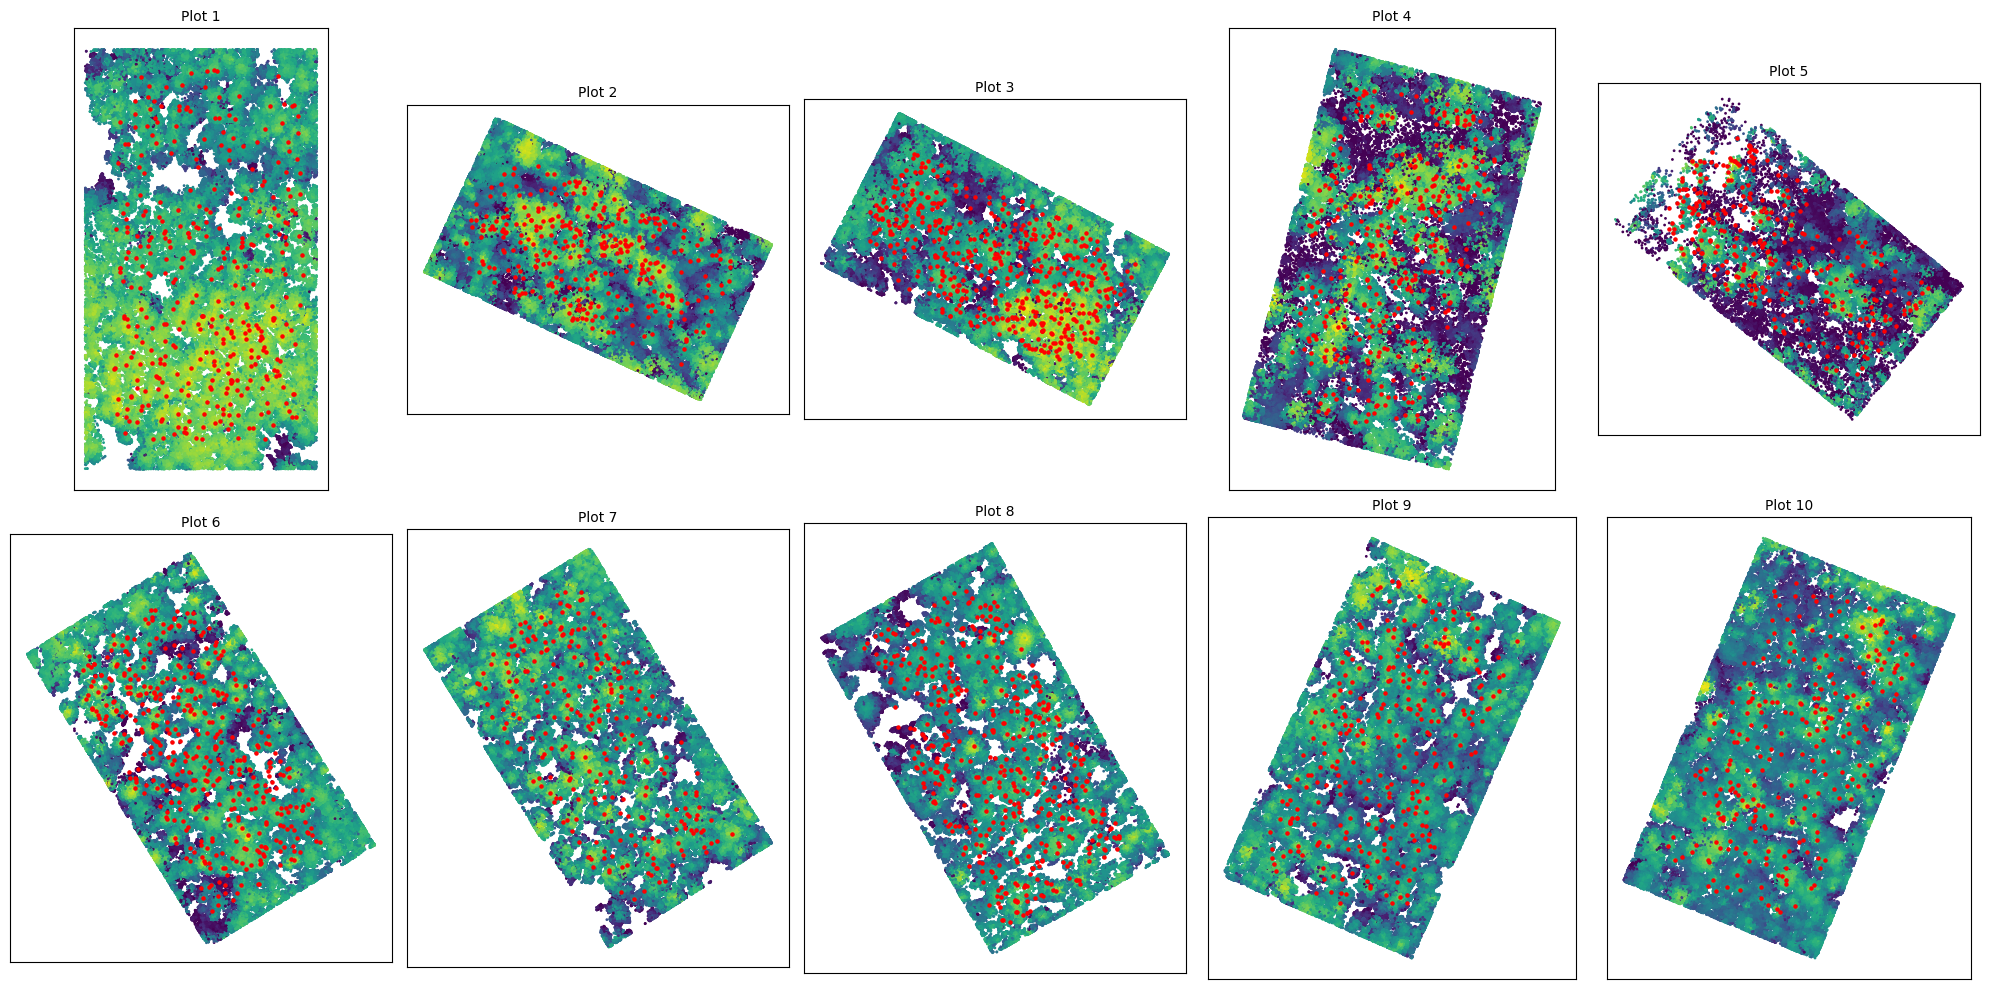

In [30]:
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for idx, (plot, matches) in enumerate(raw_matches.items()):  
    cloud = preprocessed_data[plot - 1]  
    local_maxima = np.array([
        m["candidate"] for m in matches if m["class"] in ["TP", "FP"]
    ])

    ax = axes[idx]

    sc = ax.scatter(cloud[:, 0], cloud[:, 1], c=cloud[:, 2], s=1, cmap="viridis")
    
    # Plot local maxima in red
    if len(local_maxima) > 0:
        ax.scatter(local_maxima[:, 0], local_maxima[:, 1], c="red", s=5, label="Local Maxima")
    
    ax.set_title(f"Plot {plot}", fontsize=10)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()


#### Convert Point Cloud to Voxel Grid

In [96]:
vsize_list = []
for idx, point_cloud in enumerate(preprocessed_data[:10]): 
    pcd = o3d.geometry.PointCloud()
    
    # Convert the point cloud to Open3D compatible format
    pcd.points = o3d.utility.Vector3dVector(point_cloud)
    
    # Calculate the voxel size
    vsize = max(pcd.get_max_bound() - pcd.get_min_bound()) * 0.005
    vsize = round(vsize, 4)
    vsize_list.append(vsize)
    # Print the voxel size with plot index
    print(f"Plot {idx+1} voxel size: {vsize}")

# voxel size to use for all plots
print('--'*20)
voxel_size = round(min(vsize_list), 2)
print(f"\nChosen voxel size for all plots: {voxel_size}")

Plot 1 voxel size: 0.5528
Plot 2 voxel size: 0.649
Plot 3 voxel size: 0.6491
Plot 4 voxel size: 0.6278
Plot 5 voxel size: 0.6346
Plot 6 voxel size: 0.6438
Plot 7 voxel size: 0.6528
Plot 8 voxel size: 0.6504
Plot 9 voxel size: 0.6476
Plot 10 voxel size: 0.6424
----------------------------------------

Chosen voxel size for all plots: 0.55


In [97]:
output_dir = "../results/voxels/"
voxel_grids = []

for i, data in enumerate(preprocessed_data[:10], start=1):
    file_name = f"plot_{i:02d}_v.ply" 
    file_path = output_dir + file_name
    
    # Convert to voxel grid and save
    voxel_grid = to_voxel_grid(data, voxel_size, file_path)
    voxel_grids.append(voxel_grid)
    print(f"Converted plot {i:02d} to voxel grid and saved to {file_path}")


C:\Users\35262\AppData\Local\Temp\ipykernel_22308\3455345911.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("viridis")


Converted plot 01 to voxel grid and saved to ../results/voxels/plot_01_v.ply
Converted plot 02 to voxel grid and saved to ../results/voxels/plot_02_v.ply
Converted plot 03 to voxel grid and saved to ../results/voxels/plot_03_v.ply
Converted plot 04 to voxel grid and saved to ../results/voxels/plot_04_v.ply
Converted plot 05 to voxel grid and saved to ../results/voxels/plot_05_v.ply
Converted plot 06 to voxel grid and saved to ../results/voxels/plot_06_v.ply
Converted plot 07 to voxel grid and saved to ../results/voxels/plot_07_v.ply
Converted plot 08 to voxel grid and saved to ../results/voxels/plot_08_v.ply
Converted plot 09 to voxel grid and saved to ../results/voxels/plot_09_v.ply
Converted plot 10 to voxel grid and saved to ../results/voxels/plot_10_v.ply


In [110]:
print("\nVoxel Counts:")
for i, voxel_grid in enumerate(voxel_grids, start=1):
    num_voxels = len(voxel_grid.get_voxels())  # Count the occupied voxels
    print(f"Plot {i:02d} contains {num_voxels} voxels.")


Voxel Counts:
Plot 01 contains 56943 voxels.
Plot 02 contains 100770 voxels.
Plot 03 contains 74134 voxels.
Plot 04 contains 73455 voxels.
Plot 05 contains 42181 voxels.
Plot 06 contains 73517 voxels.
Plot 07 contains 69138 voxels.
Plot 08 contains 67419 voxels.
Plot 09 contains 76559 voxels.
Plot 10 contains 77731 voxels.


In [ ]:
#load_and_visualize_voxel_grid("../results/voxels/plot_01_v.ply")

Successfully loaded and visualized voxel grid from ../results/voxels/plot_01_v.ply


In [115]:
voxel_grids[0].get_voxels()

[Voxel with grid_index: (71, 180, 21), color: (0.157851, 0.683765, 0.501686),
 Voxel with grid_index: (109, 13, 16), color: (0.139165, 0.533812, 0.555257),
 Voxel with grid_index: (86, 104, 23), color: (0.202219, 0.715272, 0.476084),
 Voxel with grid_index: (99, 25, 5), color: (0.270595, 0.214069, 0.507052),
 Voxel with grid_index: (97, 1, 23), color: (0.235466, 0.73358, 0.457826),
 Voxel with grid_index: (73, 2, 27), color: (0.475988, 0.820993, 0.319102),
 Voxel with grid_index: (14, 128, 18), color: (0.122411, 0.58758, 0.545854),
 Voxel with grid_index: (99, 54, 19), color: (0.119699, 0.61849, 0.536347),
 Voxel with grid_index: (98, 24, 2), color: (0.281805, 0.0883295, 0.411165),
 Voxel with grid_index: (2, 9, 25), color: (0.327796, 0.77398, 0.40664),
 Voxel with grid_index: (32, 39, 28), color: (0.535621, 0.835785, 0.281908),
 Voxel with grid_index: (45, 127, 22), color: (0.172534, 0.695556, 0.49288),
 Voxel with grid_index: (23, 187, 18), color: (0.123608, 0.581226, 0.547533),
 Vox

In [116]:
voxel = voxel_grids[0]
# Get the occupied voxel indices
voxel_indices = [voxel.grid_index for voxel in voxel_grid.get_voxels()]

# Convert to a numpy array for processing
voxel_indices = np.array(voxel_indices)

# Determine the grid size (bounding box of the voxel grid)
grid_min = voxel_indices.min(axis=0)
grid_max = voxel_indices.max(axis=0)
grid_size = grid_max - grid_min + 1

# Initialize a 3D binary matrix
binary_voxel = np.zeros(grid_size, dtype=np.uint8)

# Fill the binary matrix with 1s where voxels are present
for index in voxel_indices:
    adjusted_index = index - grid_min  # Shift indices to start at 0
    binary_voxel[tuple(adjusted_index)] = 1

In [118]:
np.sum(binary_voxel)

np.uint64(77731)

### up to here should be ok

In [40]:

# Create a PointCloud object
xyz = preprocessed_data[0]
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(xyz)

# Define voxel size and create a voxel grid
#vsize = max(pcd.get_max_bound() - pcd.get_min_bound()) * 0.005
#vsize = round(vsize, 4)
voxel_grid = o3d.geometry.VoxelGrid.create_from_point_cloud(pcd, voxel_size=voxel_size)

# Get the occupied voxel indices
voxel_indices = [voxel.grid_index for voxel in voxel_grid.get_voxels()]

# Convert to a numpy array for processing
voxel_indices = np.array(voxel_indices)

# Determine the grid size (bounding box of the voxel grid)
grid_min = voxel_indices.min(axis=0)
grid_max = voxel_indices.max(axis=0)
grid_size = grid_max - grid_min + 1

# Initialize a 3D binary matrix
binary_voxel = np.zeros(grid_size, dtype=np.uint8)

# Fill the binary matrix with 1s where voxels are present
for index in voxel_indices:
    adjusted_index = index - grid_min  # Shift indices to start at 0
    binary_voxel[tuple(adjusted_index)] = 1

# Visualize the binary voxel grid (optional, convert back to Open3D VoxelGrid)
occupied_points = []
for idx, value in np.ndenumerate(binary_voxel):
    if value == 1:
        # Convert binary indices back to coordinates
        point = grid_min + np.array(idx)
        occupied_points.append(point * vsize)  # Scale back to original units

# Create a voxel grid from the binary matrix for visualization
binary_voxel_pcd = o3d.geometry.PointCloud()
binary_voxel_pcd.points = o3d.utility.Vector3dVector(np.array(occupied_points))
binary_voxel_grid = o3d.geometry.VoxelGrid.create_from_point_cloud(binary_voxel_pcd, voxel_size=vsize)

# Visualize the binary voxel grid
o3d.visualization.draw_geometries([binary_voxel_grid])


In [42]:
len(preprocessed_data[0])

186897

In [41]:
len(occupied_points)

56943

In [ ]:
voxel_size = 0.55  # Size of the voxel in meters
binary_voxel_arrays = []  
voxel_grids = []  

for i, points in enumerate(preprocessed_data):  
    # Create Open3D VoxelGrid
    voxel_grid = point_cloud_to_voxel_grid(points, voxel_size=voxel_size)
    voxel_grids.append(voxel_grid)  
    
    # Convert to binary 3D array
    binary_voxel_array = voxel_grid_to_array(voxel_grid, voxel_size)
    binary_voxel_arrays.append(binary_voxel_array)

    # Count the number of occupied voxels
    occupied_voxel_count = np.sum(binary_voxel_array)

    print(f"Plot {i + 1}:")
    print(f"  Total Occupied Voxels: {occupied_voxel_count}")
    print(f"  Voxel Array Shape (X, Y, Z): {binary_voxel_array.shape}\n")


Plot 1:
  Total Occupied Voxels: 172357
  Voxel Array Shape (X, Y, Z): (611, 1108, 189)

Plot 2:
  Total Occupied Voxels: 316490
  Voxel Array Shape (X, Y, Z): (1300, 1051, 289)

Plot 3:
  Total Occupied Voxels: 245242
  Voxel Array Shape (X, Y, Z): (1300, 1090, 260)

Plot 4:
  Total Occupied Voxels: 216689
  Voxel Array Shape (X, Y, Z): (890, 1258, 300)

Plot 5:
  Total Occupied Voxels: 95544
  Voxel Array Shape (X, Y, Z): (1270, 1173, 290)

Plot 6:
  Total Occupied Voxels: 226536
  Voxel Array Shape (X, Y, Z): (1150, 1290, 293)

Plot 7:
  Total Occupied Voxels: 249856
  Voxel Array Shape (X, Y, Z): (1141, 1308, 161)

Plot 8:
  Total Occupied Voxels: 207583
  Voxel Array Shape (X, Y, Z): (1105, 1303, 288)

Plot 9:
  Total Occupied Voxels: 252046
  Voxel Array Shape (X, Y, Z): (1032, 1296, 226)

Plot 10:
  Total Occupied Voxels: 271851
  Voxel Array Shape (X, Y, Z): (1012, 1286, 206)



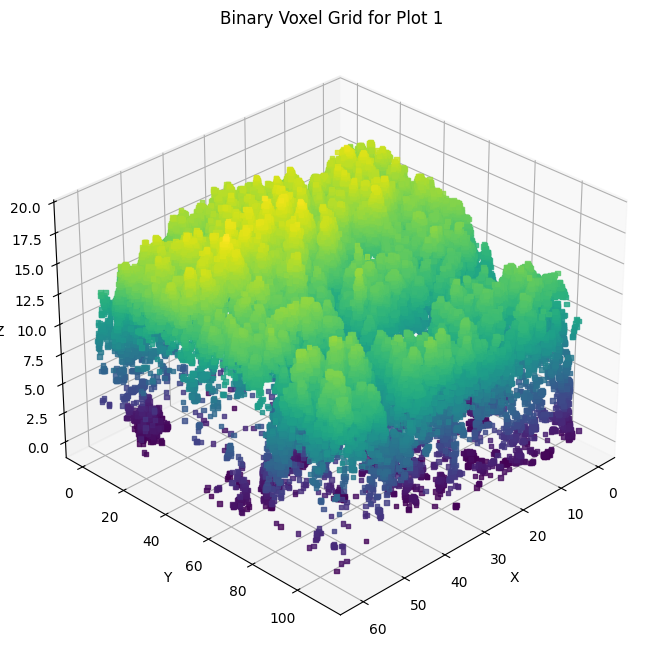

In [76]:
visualize_binary_voxel_grid(binary_voxel_arrays[0], title="Binary Voxel Grid for Plot 1", voxel_size=0.1)

In [ ]:
voxel_grid = o3d.geometry.VoxelGrid.create_from_point_cloud(pcd, voxel_size = vsize)
bounds = voxel_grid.get_max_bound()-voxel_grid.get_min_bound()
o3d.visualization.draw_geometries([voxel_grid])

In [122]:
o3d.visualization.draw_geometries([voxel_grids[0]])

In [124]:
len(voxel_grid.get_voxels())

70722

In [125]:
vsize

np.float64(0.5528)

In [166]:
preprocessed_data[0].shape

(186897, 3)

In [61]:

xyz=preprocessed_data[0]
# Create a PointCloud object
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(xyz)

# Define voxel size and create a voxel grid
vsize = max(pcd.get_max_bound() - pcd.get_min_bound()) * 0.005
vsize = round(vsize, 4)
voxel_grid = o3d.geometry.VoxelGrid.create_from_point_cloud(pcd, voxel_size=vsize)

# Visualize the voxel grid
o3d.visualization.draw_geometries([voxel_grid])


[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 


In [ ]:
def plot_voxel_grid(voxel_grid: o3d.geometry.VoxelGrid, voxel_size: float, title="Voxel Grid with Viridis"):
    """
    Visualize a voxel grid as full cubes with a Viridis colormap applied based on Z-coordinate.
    """
    # Get occupied voxels
    voxels = voxel_grid.get_voxels()

    # Extract voxel centers
    voxel_centers = np.array([voxel.grid_index for voxel in voxels]) * voxel_size

    # Apply Viridis colormap based on Z-coordinate
    cmap = get_cmap("viridis")
    norm = mcolors.Normalize(vmin=voxel_centers[:, 2].min(), vmax=voxel_centers[:, 2].max())
    colors = cmap(norm(voxel_centers[:, 2]))[:, :3]  # Extract RGB values

    # Create a PointCloud for the voxel grid centers
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(voxel_centers)
    pcd.colors = o3d.utility.Vector3dVector(colors)

    # Create a voxel grid from the PointCloud
    colored_voxel_grid = o3d.geometry.VoxelGrid.create_from_point_cloud(pcd, voxel_size=voxel_size)

    # Visualize the voxel grid
    o3d.visualization.draw_geometries([colored_voxel_grid], window_name=title)


In [68]:
labeled_voxel_arrays = []  

for plot_number, voxel_array in enumerate(binary_voxel_arrays):
    voxel_grid = voxel_grids[plot_number]  
    min_bound = voxel_grid.get_min_bound()  

    labeled_voxel_array = np.zeros_like(voxel_array, dtype=np.uint8)  
    plot_ground_truth = field_survey_gpd[field_survey_gpd["plot"] == plot_number + 1]  

    for _, row in plot_ground_truth.iterrows():
        x, y = row['coords']  
        voxel_x, voxel_y = world_to_voxel_indices(x, y, min_bound, voxel_size)

        # Check bounds and label voxel
        if 0 <= voxel_x < labeled_voxel_array.shape[0] and \
           0 <= voxel_y < labeled_voxel_array.shape[1]:
            labeled_voxel_array[voxel_x, voxel_y, :] = 1

    labeled_voxel_arrays.append(labeled_voxel_array)


In [51]:
def world_to_voxel_indices(x, y, voxel_grid, voxel_size):
    """
    Convert world coordinates (x, y) to voxel grid indices.
    Dynamically extract the min_bound from the voxel grid.
    """
    # Extract min bounds from the voxel grid
    min_bound = np.array(voxel_grid.get_min_bound())
    
    # Calculate voxel indices
    voxel_x = int(np.floor((x - min_bound[0]) / voxel_size))
    voxel_y = int(np.floor((y - min_bound[1]) / voxel_size))
    return voxel_x, voxel_y


In [33]:
def map_ground_truth_to_voxel_labels(gpd_coords, voxel_min_bound, voxel_size, grid_shape):
    """
    Map ground truth coordinates (x, y) to binary voxel grid.

    Parameters:
    - gpd_coords (np.ndarray): Ground truth (x, y) coordinates from GeoDataFrame.
    - voxel_min_bound (tuple): Minimum bounds of the voxel grid.
    - voxel_size (float): Voxel size in meters.
    - grid_shape (tuple): Shape of the voxel grid (X, Y, Z).

    Returns:
    - binary_labels (np.ndarray): Binary voxel grid with labels.
    """
    # Shift coordinates and map to grid indices
    shifted_coords = gpd_coords - voxel_min_bound[:2]
    grid_indices = np.floor(shifted_coords / voxel_size).astype(int)

    # Initialize binary label grid
    binary_labels = np.zeros(grid_shape, dtype=np.uint8)

    # Set tree positions to 1
    for idx in grid_indices:
        x, y = idx[:2]
        if 0 <= x < grid_shape[0] and 0 <= y < grid_shape[1]:
            binary_labels[x, y, :] = 1  # Mark as occupied for the entire Z-axis

    return binary_labels


In [34]:
binary_label_arrays = []

for i, points in enumerate(preprocessed_data):
    # Retrieve voxel grid minimum bounds
    voxel_min_bound = voxel_min_bounds[i]

    # Ground truth data for the current plot
    plot_gpd = field_survey_gpd.query(f"plot == {i + 1}")
    gpd_coords = np.array([coord for coord in plot_gpd["coords"]])
    
    # Create binary labels
    binary_labels = map_ground_truth_to_voxel_labels(
        gpd_coords,
        voxel_min_bound,
        voxel_size,
        binary_voxel_arrays[i].shape  # Shape of the voxel grid
    )
    
    binary_label_arrays.append(binary_labels)

    print(f"Plot {i + 1} Label Shape: {binary_labels.shape}")


Plot 1 Label Shape: (611, 1108, 189)
Plot 2 Label Shape: (1300, 1051, 289)
Plot 3 Label Shape: (1300, 1090, 260)
Plot 4 Label Shape: (890, 1258, 300)
Plot 5 Label Shape: (1270, 1173, 290)
Plot 6 Label Shape: (1150, 1290, 293)
Plot 7 Label Shape: (1141, 1308, 161)
Plot 8 Label Shape: (1105, 1303, 288)
Plot 9 Label Shape: (1032, 1296, 226)
Plot 10 Label Shape: (1012, 1286, 206)


In [35]:
def project_to_2d(voxel_array):
    """
    Collapse the Z dimension of a 3D voxel grid to create a 2D grid (top-down view).
    """
    # Sum along the Z-axis (height dimension)
    projected_2d = np.sum(voxel_array, axis=2)  # Collapse Z-axis
    # Convert to binary (1 if any voxel in the column is occupied, else 0)
    projected_2d = (projected_2d > 0).astype(np.uint8)
    return projected_2d

# Apply projection to all voxel grids
binary_voxel_arrays_2d = [project_to_2d(arr) for arr in binary_voxel_arrays]


In [36]:
# Apply projection to all label arrays
binary_label_arrays_2d = [project_to_2d(arr) for arr in binary_label_arrays]


In [37]:
for i in range(len(binary_voxel_arrays_2d)):
   print(binary_voxel_arrays_2d[i].shape)

(611, 1108)
(1300, 1051)
(1300, 1090)
(890, 1258)
(1270, 1173)
(1150, 1290)
(1141, 1308)
(1105, 1303)
(1032, 1296)
(1012, 1286)


In [38]:
for i in range(len(binary_label_arrays_2d)):
   print(binary_label_arrays_2d[i].shape)

(611, 1108)
(1300, 1051)
(1300, 1090)
(890, 1258)
(1270, 1173)
(1150, 1290)
(1141, 1308)
(1105, 1303)
(1032, 1296)
(1012, 1286)


In [39]:
import numpy as np

def pad_2d_array(array, target_shape):
    """
    Pad a 2D array to match the target shape with zeros.

    Parameters:
    - array (np.ndarray): The 2D array to pad.
    - target_shape (tuple): The target shape (rows, cols).

    Returns:
    - padded_array (np.ndarray): The padded 2D array.
    """
    pad_height = target_shape[0] - array.shape[0]
    pad_width = target_shape[1] - array.shape[1]
    padded_array = np.pad(array, 
                          pad_width=((0, pad_height), (0, pad_width)), 
                          mode='constant', 
                          constant_values=0)
    return padded_array

# Find the largest dimensions
max_height = max([arr.shape[0] for arr in binary_voxel_arrays_2d])
max_width = max([arr.shape[1] for arr in binary_voxel_arrays_2d])
max_shape = (max_height, max_width)

# Pad all voxel arrays and label arrays
padded_voxel_arrays_2d = [pad_2d_array(arr, max_shape) for arr in binary_voxel_arrays_2d]
padded_label_arrays_2d = [pad_2d_array(arr, max_shape) for arr in binary_label_arrays_2d]

# Convert to NumPy arrays
X = np.array(padded_voxel_arrays_2d)
y = np.array(padded_label_arrays_2d)

print(f"All arrays padded to shape: {max_shape}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")


All arrays padded to shape: (1300, 1308)
X shape: (10, 1300, 1308)
y shape: (10, 1300, 1308)


In [40]:
# Add a channel dimension to X (e.g., (10, 1300, 1308, 1))
X = np.expand_dims(X, axis=-1)

# Add a channel dimension to y (e.g., (10, 1300, 1308, 1))
y = np.expand_dims(y, axis=-1)

print(f"X shape after adding channel: {X.shape}")
print(f"y shape after adding channel: {y.shape}")


X shape after adding channel: (10, 1300, 1308, 1)
y shape after adding channel: (10, 1300, 1308, 1)


In [41]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape: {X_test.shape}")


Training Data Shape: (8, 1300, 1308, 1)
Testing Data Shape: (2, 1300, 1308, 1)


In [ ]:
# we shoud

In [117]:
# Define a 2D CNN model
def build_2d_cnn(input_shape):
    model = models.Sequential()
    model.add(layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Conv2D(64, kernel_size=(3, 3), activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Conv2D(128, kernel_size=(3, 3), activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid'))  # Binary classification
    return model

# Build the model
input_shape = X_train.shape[1:]  # Shape: (1300, 1308, 1)
model = build_2d_cnn(input_shape)

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()


(186897, 3)
(355599, 3)
(282788, 3)
(251251, 3)
(105771, 3)
(263587, 3)
(284775, 3)
(240625, 3)
(289525, 3)
(307468, 3)


#### Advanced DNN architecture

### Comparison

In [105]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv3D, MaxPooling3D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [118]:
# Create synthetic data
num_samples = 100
img_depth, img_height, img_width = 30, 64, 64  # Dimensions of the 3D images
num_classes = 2  # Number of classes for classification
 
# Generate random 3D images and labels
X_train = np.random.rand(num_samples, img_depth, img_height, img_width, 1)
y_train = np.random.randint(0, num_classes, num_samples)
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
 
# Split the data into training and validation sets
split_idx = int(0.8 * num_samples)
X_val = X_train[split_idx:]
y_val = y_train[split_idx:]
X_train = X_train[:split_idx]
y_train = y_train[:split_idx]

In [119]:
print(X_train.shape)
print(y_train.shape)
print(X_val.shape)
print(y_val.shape)

(80, 30, 64, 64, 1)
(80, 2)
(20, 30, 64, 64, 1)
(20, 2)


In [107]:
model = Sequential()
 
# First convolutional layer
model.add(Conv3D(32, kernel_size=(3, 3, 3), activation='relu', input_shape=(img_depth, img_height, img_width, 1)))
model.add(MaxPooling3D(pool_size=(2, 2, 2)))
 
# Second convolutional layer
model.add(Conv3D(64, kernel_size=(3, 3, 3), activation='relu'))
model.add(MaxPooling3D(pool_size=(2, 2, 2)))
 
# Third convolutional layer
model.add(Conv3D(128, kernel_size=(3, 3, 3), activation='relu'))
model.add(MaxPooling3D(pool_size=(2, 2, 2)))
 
# Flatten the 3D feature maps
model.add(Flatten())
 
# Fully connected layer
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
 
# Output layer
model.add(Dense(num_classes, activation='softmax'))

d:\LiDAR-Based-Tree-Detection\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [108]:
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [109]:
model.fit(X_train, y_train, epochs=10, batch_size=8, validation_data=(X_val, y_val))

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 264ms/step - accuracy: 0.4970 - loss: 0.8341 - val_accuracy: 0.5500 - val_loss: 0.6890
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 226ms/step - accuracy: 0.4186 - loss: 0.7018 - val_accuracy: 0.4500 - val_loss: 0.7021
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 227ms/step - accuracy: 0.5404 - loss: 0.6982 - val_accuracy: 0.4500 - val_loss: 0.6949
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 218ms/step - accuracy: 0.4766 - loss: 0.6945 - val_accuracy: 0.4500 - val_loss: 0.6939
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 212ms/step - accuracy: 0.5639 - loss: 0.6927 - val_accuracy: 0.4500 - val_loss: 0.6943
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 212ms/step - accuracy: 0.4427 - loss: 0.6942 - val_accuracy: 0.4500 - val_loss: 0.6944
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 216ms/step - accuracy: 0.5706 - loss: 0.6904 - val_accuracy: 0.4500 - val_loss: 0.6954
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 219ms/step - accuracy: 0.5077 - loss: 0.6932 - val_accuracy: 0.

In [110]:
val_loss, val_accuracy = model.evaluate(X_val, y_val)
print(f'Validation Loss: {val_loss:.4f}')
print(f'Validation Accuracy: {val_accuracy:.4f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.4500 - loss: 0.6963
Validation Loss: 0.6963
Validation Accuracy: 0.4500
